   Age  Income  CreditScore  LoanApproved
0   25   30000          650             0
1   35   60000          720             1
2   45   80000          780             1
3   23   25000          600             0
4   52   90000          800             1
5   43   70000          750             1
6   36   65000          710             1
7   28   32000          640             0
8   40   72000          770             1
9   50   85000          790             1
[1 1]
accuracy_score  1.0
classification_report                precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



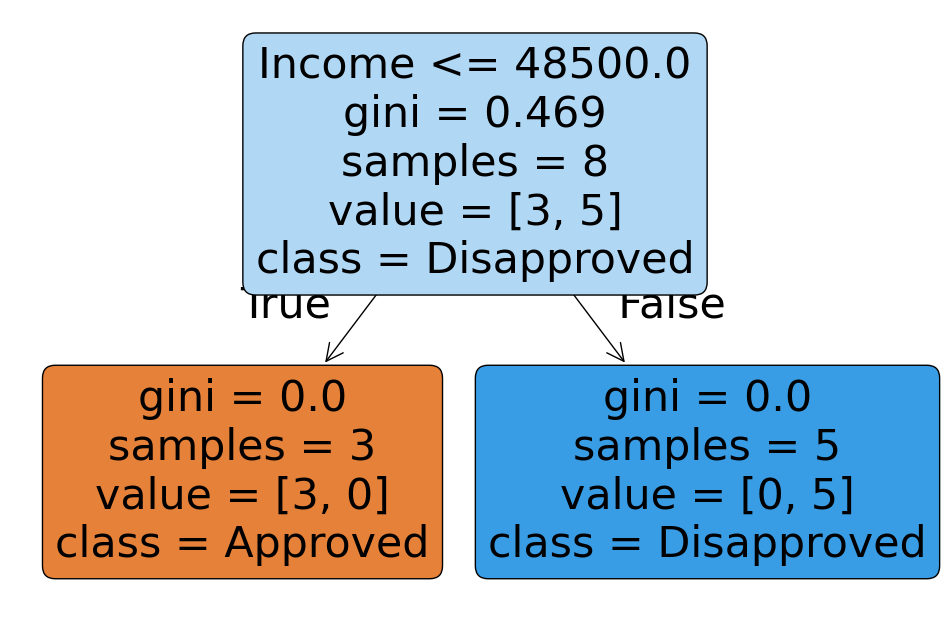

Loan Approved


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pickle

data = {
    'Age': [25, 35, 45, 23, 52, 43, 36, 28, 40, 50],
    'Income': [30000, 60000, 80000, 25000, 90000,
               70000, 65000, 32000, 72000, 85000],
    'CreditScore': [650, 720, 780, 600, 800,
                    750, 710, 640, 770, 790],
    'LoanApproved': [0, 1, 1, 0, 1,
                     1, 1, 0, 1, 1]
}
f_data = pd.DataFrame(data)
print(f_data)
x = f_data[['Age', 'Income', 'CreditScore']]
y = f_data['LoanApproved']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(criterion = 'gini',max_depth = 5,random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(y_pred)
print('accuracy_score ', accuracy_score(y_test, y_pred))
print('classification_report ', classification_report(y_test, y_pred))

plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names = x.columns,
    class_names = ['Approved', 'Disapproved'],
    filled=True,
    rounded=True
)
plt.show()

new_customer = pd.DataFrame({
    'Age': [38],
    'Income': [70000],
    'CreditScore': [750]
})

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

with open(r"D:\Python-Course\ML-Course\test\Machine-Learning-Algorithm\Decision-Tree-Classifier\loan_approval_model.pkl", "wb") as f:
    pickle.dump(model, f)